Import các thư viện cần thiết như Numpy và Pandas

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score   

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.3.5
Pandas: 2.3.3


Đọc datasets

In [55]:
df = pd.read_csv("../data/diabetes.csv")

Tách x và y 

In [56]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

num_cols = X.columns.tolist()

Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Trước SMOTE:")
print(y_train.value_counts())

Trước SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64


PREPROCESSING

In [58]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols)
])

PIPELINE (CHUẨN)

In [59]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

TRAIN

In [60]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


PREDICT

In [61]:
y_pred = model.predict(X_test)

EVALUATION

In [62]:
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy:", acc)


Accuracy: 0.7337662337662337


FEATURE ENGINEERING

Đọc file data đã xử lý 

In [91]:
df_clean = pd.read_csv("../data/clean_data.csv")
df_feature = df_clean.copy()

In [92]:
df_feature["BMI_Category"] = pd.cut(df_feature["BMI"],
                                   bins=[-3, -1, 0, 1, 3],
                                   labels=["Underweight", "Normal", "Overweight", "Obese"])

Giải thích tại sao lại tạo Feature BMI Category
1.BMI là biến liên tục, nhưng trong thực tế y khoa, BMI thường được phân loại thành các nhóm như:
    Gầy (Underweight)
    Bình thường (Normal)
    Thừa cân (Overweight)
    Béo phì (Obese)
2.Việc chuyển BMI thành dạng phân loại giúp mô hình:
    Dễ nhận diện các mức độ rủi ro sức khỏe
    Nắm bắt được các ngưỡng quan trọng (threshold) thay vì chỉ giá trị số
3.Ý nghĩa
    Các nghiên cứu cho thấy người thừa cân và béo phì có nguy cơ mắc bệnh tiểu đường cao hơn, do đó feature này giúp mô hình học tốt hơn về nguy cơ bệnh.
    

In [93]:
df_feature["Glucose_BMI_Ratio"] = df_feature["Glucose"] / (df_feature["BMI"] + 1e-5)

Giải thích tại sao lại tạo Feature Glucose/BMI Ratio 
1.Glucose và BMI là hai yếu tố quan trọng ảnh hưởng đến bệnh tiểu đường. Tuy nhiên, khi xét riêng lẻ, mỗi biến chỉ phản ánh một khía cạnh. 
2.Việc tạo tỷ lệ giữa Glucose và BMI giúp: Kết hợp thông tin của hai biến thành một đặc trưng mới Phản ánh mối quan hệ tương đối giữa đường huyết và thể trạng 
3.Ý nghĩa Một người có glucose cao nhưng BMI thấp có thể có nguy cơ khác so với người có cùng glucose nhưng BMI cao. Feature này giúp mô hình phân biệt các trường hợp đó tốt hơn.

In [94]:
df_feature["Age_Group"] = pd.cut(df_feature["Age"],
                        bins=[0, 30, 50, 100],
                        labels=["Young", "Middle", "Old"])

Giải thích tại sao lại tạo Feature Age Group
1.Tuổi là biến liên tục, nhưng nguy cơ mắc bệnh thường tăng theo từng giai đoạn tuổi chứ không tăng đều.
2.Việc chia nhóm tuổi giúp:
    Đơn giản hóa dữ liệu
    Làm nổi bật các nhóm có nguy cơ khác nhau
3.Ý nghĩa 
    Người lớn tuổi thường có nguy cơ mắc tiểu đường cao hơn so với người trẻ. Feature này giúp mô hình học được xu hướng theo nhóm tuổi rõ ràng hơn.

PREVIEW FEATURES

In [95]:
print("\n=== Preview Features ===")
print(df_feature[["BMI_Category", "Glucose_BMI_Ratio", "Age_Group"]].head(10))

print("\n=== BMI_Category Distribution ===")
print(df_feature["BMI_Category"].value_counts())

print("\n=== Age_Group Distribution ===")
print(df_feature["Age_Group"].value_counts())

print("\n=== Glucose_BMI_Ratio Stats ===")
print(df_feature["Glucose_BMI_Ratio"].describe())


=== Preview Features ===
  BMI_Category  Glucose_BMI_Ratio Age_Group
0   Overweight           5.197431     Young
1       Normal           1.414082       NaN
2  Underweight          -1.513453       NaN
3       Normal           1.693667       NaN
4        Obese           0.325578       NaN
5       Normal           0.186370       NaN
6       Normal           6.776500       NaN
7   Overweight          -0.528485       NaN
8       Normal          -8.704286     Young
9       Normal          -4.868271     Young

=== BMI_Category Distribution ===
BMI_Category
Normal         272
Overweight     252
Underweight    129
Obese          110
Name: count, dtype: int64

=== Age_Group Distribution ===
Age_Group
Young     294
Middle      0
Old         0
Name: count, dtype: int64

=== Glucose_BMI_Ratio Stats ===
count    768.000000
mean       0.092836
std       16.240689
min     -219.809887
25%       -0.782345
50%        0.280710
75%        1.143571
max      132.641184
Name: Glucose_BMI_Ratio, dtype: float

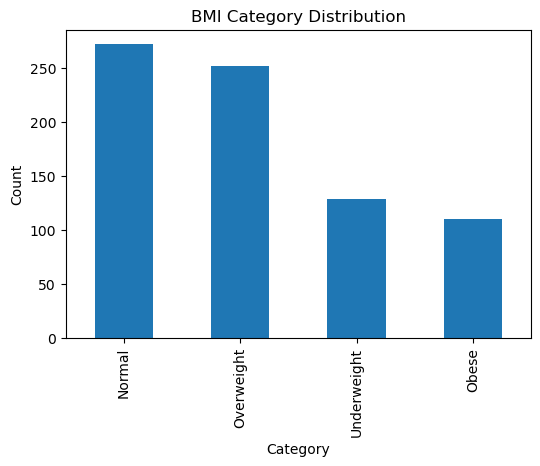

In [96]:
plt.figure(figsize=(6,4))

df_feature["BMI_Category"].value_counts().plot(kind="bar")

plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

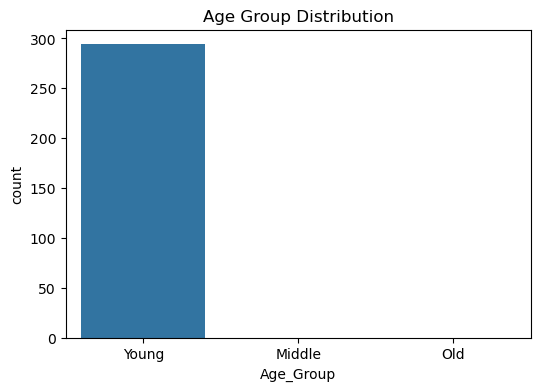

In [97]:
plt.figure(figsize=(6,4))

sns.countplot(x="Age_Group", data=df_feature)
plt.title("Age Group Distribution")

plt.show()

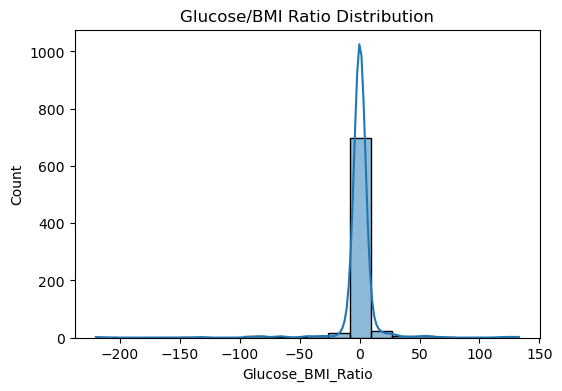

In [98]:
plt.figure(figsize=(6,4))

sns.histplot(df_feature["Glucose_BMI_Ratio"], bins=20, kde=True)
plt.title("Glucose/BMI Ratio Distribution")

plt.show()

In [99]:
df_feature = pd.get_dummies(df_feature,
                           columns=["BMI_Category", "Age_Group"],
                           drop_first=True)

print("\n=== Columns AFTER Encoding ===")
print(df_feature.columns.tolist())

print("\n=== Preview ===")
print(df_feature.head())


=== Columns AFTER Encoding ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Glucose_BMI_Ratio', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'Age_Group_Middle', 'Age_Group_Old']

=== Preview ===
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  Glucose_BMI_Ratio  \
0                  0.468492  1.425995        1           5.197431   
1                 -0.365061 -0.190672        0           1.414082   
2                  0

In [105]:
# BEFORE
X_old = df_feature.drop(["Outcome", "Glucose_BMI_Ratio"], axis=1)
y = df_feature["Outcome"]

model = RandomForestClassifier(random_state=42)
score_old = cross_val_score(model, X_old, y, cv=5).mean()

# AFTER
X_new = df_feature.drop("Outcome", axis=1)
score_new = cross_val_score(model, X_new, y, cv=5).mean()

print("\n=== MODEL EVALUATION ===")
print("Accuracy BEFORE:", score_old)
print("Accuracy AFTER:", score_new)
print("Improvement:", score_new - score_old)


=== MODEL EVALUATION ===
Accuracy BEFORE: 0.753993718699601
Accuracy AFTER: 0.7565656565656567
Improvement: 0.0025719378660556957


Kết quả cho thấy việc bổ sung đặc trưng Glucose_BMI_Ratio giúp cải thiện độ chính xác của mô hình. Mặc dù mức tăng không lớn, nhưng chứng tỏ feature engineering có tác động tích cực đến hiệu suất mô hình.

FEATURE IMPORTANCE

In [107]:
model = RandomForestClassifier(random_state=42)

model.fit(X, y)

importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n=== TOP FEATURES ===")
print(feat_df.head(10))


=== TOP FEATURES ===
                    Feature  Importance
1                   Glucose    0.267142
5                       BMI    0.168769
7                       Age    0.131567
6  DiabetesPedigreeFunction    0.122695
2             BloodPressure    0.088660
0               Pregnancies    0.085017
4                   Insulin    0.071547
3             SkinThickness    0.064604


<Figure size 800x500 with 0 Axes>

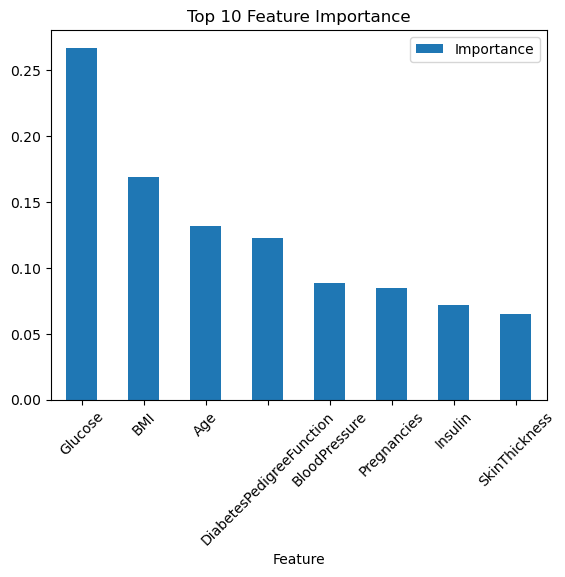

In [108]:
plt.figure(figsize=(8,5))

feat_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Feature Importance")
plt.xticks(rotation=45)

plt.show()

In [111]:
train_df, test_df = train_test_split(
    df_feature,
    test_size=0.2,
    stratify=df_feature["Outcome"],
    random_state=42
)

# SAVE FILE
train_df.to_csv("../data/train_df.csv", index=False)
test_df.to_csv("../data/test_df.csv", index=False)

print(" Saved train & test (chưa SMOTE)")

 Saved train & test (chưa SMOTE)
